# Logistic Regression

In [162]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [163]:
df = pd.read_csv("C:/Users/84333/projects/DeepLearningCourse/Data/diabetes2.csv")

In [164]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [165]:
_X1 = np.array(df["Pregnancies"])
_X2 = np.array(df["Glucose"])
_X3 = np.array(df["BloodPressure"])
_X4 = np.array(df["SkinThickness"])
_X5 = np.array(df["Insulin"])
_X6 = np.array(df["BMI"])
_X7 = np.array(df["DiabetesPedigreeFunction"])
_X8 = np.array(df["Age"])
_Y = np.array(df["Outcome"])

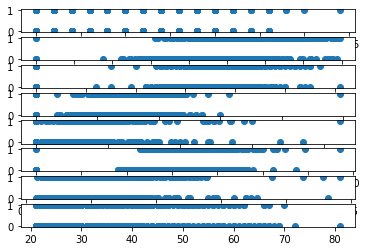

In [166]:
plt.subplot(8, 1, 1)
plt.scatter(_X1, _Y)
plt.subplot(8, 1, 2)
plt.scatter(_X2, _Y)
plt.subplot(8, 1, 3)
plt.scatter(_X3, _Y)
plt.subplot(8, 1, 4)
plt.scatter(_X4, _Y)
plt.subplot(8, 1, 5)
plt.scatter(_X5, _Y)
plt.subplot(8, 1, 6)
plt.scatter(_X6, _Y)
plt.subplot(8, 1, 7)
plt.scatter(_X7, _Y)
plt.subplot(8, 1, 8)
plt.scatter(_X8, _Y)

In [167]:
X1 = _X2[0:760]
X2 = _X3[0:760]
X3 = _X4[0:760]
X4 = _X5[0:760]
X5 = _X6[0:760] 
X6 = _X7[0:760]
X7 = _X8[0:760]
Y = _Y[0:760]
X1

array([148,  85, 183,  89, 137, 116,  78, 115, 197, 125, 110, 168, 139,
       189, 166, 100, 118, 107, 103, 115, 126,  99, 196, 119, 143, 125,
       147,  97, 145, 117, 109, 158,  88,  92, 122, 103, 138, 102,  90,
       111, 180, 133, 106, 171, 159, 180, 146,  71, 103, 105, 103, 101,
        88, 176, 150,  73, 187, 100, 146, 105,  84, 133,  44, 141, 114,
        99, 109, 109,  95, 146, 100, 139, 126, 129,  79,   0,  62,  95,
       131, 112, 113,  74,  83, 101, 137, 110, 106, 100, 136, 107,  80,
       123,  81, 134, 142, 144,  92,  71,  93, 122, 163, 151, 125,  81,
        85, 126,  96, 144,  83,  95, 171, 155,  89,  76, 160, 146, 124,
        78,  97,  99, 162, 111, 107, 132, 113,  88, 120, 118, 117, 105,
       173, 122, 170,  84,  96, 125, 100,  93, 129, 105, 128, 106, 108,
       108, 154, 102,  57, 106, 147,  90, 136, 114, 156, 153, 188, 152,
        99, 109,  88, 163, 151, 102, 114, 100, 131, 104, 148, 120, 110,
       111, 102, 134,  87,  79,  75, 179,  85, 129, 143, 130,  8

In [168]:
print(np.mean(_Y))

0.3489583333333333


In [169]:
X1_mean, X1_std = X1.mean(), X1.std()
X2_mean, X2_std = X2.mean(), X2.std()
X3_mean, X3_std = X3.mean(), X3.std()
X4_mean, X4_std = X4.mean(), X4.std()
X5_mean, X5_std = X5.mean(), X5.std()
X6_mean, X6_std = X6.mean(), X6.std()
X7_mean, X7_std = X7.mean(), X7.std()
X1_scaled = (X1 - X1_mean) / X1_std
X2_scaled = (X2 - X2_mean) / X2_std
X3_scaled = (X3 - X3_mean) / X3_std
X4_scaled = (X4 - X4_mean) / X4_std
X5_scaled = (X5 - X5_mean) / X5_std
X6_scaled = (X6 - X6_mean) / X6_std
X7_scaled = (X7 - X7_mean) / X7_std

In [170]:
X1_scaled

array([ 8.44636954e-01, -1.12397607e+00,  1.93831086e+00, -9.98984767e-01,
        5.00910870e-01, -1.55293471e-01, -1.34271085e+00, -1.86541297e-01,
        2.37578042e+00,  1.25936961e-01, -3.42780426e-01,  1.46959347e+00,
        5.63406522e-01,  2.12579781e+00,  1.40709782e+00, -6.55258683e-01,
       -9.27978194e-02, -4.36523903e-01, -5.61515206e-01, -1.86541297e-01,
        1.57184787e-01, -6.86506509e-01,  2.34453259e+00, -6.15499937e-02,
        6.88397825e-01,  1.25936961e-01,  8.13389128e-01, -7.49002161e-01,
        7.50893476e-01, -1.24045645e-01, -3.74028251e-01,  1.15711521e+00,
       -1.03023259e+00, -9.05241289e-01,  3.21934837e-02, -5.61515206e-01,
        5.32158696e-01, -5.92763032e-01, -9.67736941e-01, -3.11532600e-01,
        1.84456738e+00,  3.75919567e-01, -4.67771729e-01,  1.56333695e+00,
        1.18836304e+00,  1.84456738e+00,  7.82141302e-01, -1.56144563e+00,
       -5.61515206e-01, -4.99019554e-01, -5.61515206e-01, -6.24010858e-01,
       -1.03023259e+00,  

In [171]:
def cal_loss(Y, Y_pred):
    _sum = 0
    for i in range(len(Y)):
        _sum += Y[i]*np.log(Y_pred[i]) + (1-Y[i])*np.log(1-Y_pred[i])
    return _sum/len(Y)

In [172]:
def fit(Y, X1, X2, X3, X4, X5, X6, X7, w1, w2, w3, w4, w5, w6, w7, b, epochs, lr):
    for epoch in range(epochs):
        Y_preds = []
        for i in range(len(Y)):
            Y_pred = 1/(1+np.exp(-(w1*X1[i]+w2*X2[i]+w3*X3[i]+w4*X4[i]+w5*X5[i]+w6*X6[i]+w7*X7[i]+b)))
            Y_preds.append(Y_pred)
            w1 = w1 + lr*(Y[i] - Y_pred)*X1[i]
            w2 = w2 + lr*(Y[i] - Y_pred)*X2[i]
            w3 = w3 + lr*(Y[i] - Y_pred)*X3[i]
            w4 = w4 + lr*(Y[i] - Y_pred)*X4[i]
            w5 = w5 + lr*(Y[i] - Y_pred)*X5[i]
            w6 = w6 + lr*(Y[i] - Y_pred)*X6[i]
            w7 = w7 + lr*(Y[i] - Y_pred)*X7[i]
            b = b + lr*(Y[i] - Y_pred)
        if(epoch % 100 == 0):
            print(cal_loss(Y, Y_preds))
    return (w1, w2, w3, w4, w5, w6, w7, b)

In [185]:
w1 = np.random.rand()
w2 = np.random.rand()
w3 = np.random.rand()
w4 = np.random.rand()
w5 = np.random.rand()
w6 = np.random.rand()
w7 = np.random.rand()
b = np.random.rand()
epochs = 1000
lr = 0.01

In [186]:
w1_final, w2_final ,w3_final, w4_final, w5_final, w6_final,w7_final ,b_final = fit(Y, X1_scaled, X2_scaled, X3_scaled, X4_scaled, X5_scaled, X6_scaled, X7_scaled, w1, w2, w3, w4, w5, w6, w7, b, epochs, lr)

-0.5553864697058996
-0.4893202172022536
-0.4893202172022536
-0.4893202172022536
-0.4893202172022536
-0.4893202172022536
-0.4893202172022536
-0.4893202172022536
-0.4893202172022536
-0.4893202172022536


In [191]:
w1 = w1_final/X1_std
w2 = w1_final/X2_std
w3 = w1_final/X3_std
w4 = w1_final/X4_std
w5 = w1_final/X5_std
w6 = w1_final/X6_std
w7 = w1_final/X7_std
b = b_final - (X1_mean*w1_final/X1_std) - (X2_mean*w2_final/X2_std) - (X3_mean*w3_final/X3_std) - (X4_mean*w4_final/X4_std) - (X5_mean*w5_final/X5_std) - (X6_mean*w6_final/X6_std) - (X7_mean*w7_final/X7_std)

In [192]:
Y_test = 1/(1+np.exp(-(w1*_X1[760:768]+w2*_X2[760:768]+w3*_X3[760:768]+w4*_X4[760:768]+w5*_X5[760:768]+w6*_X6[760:768]+w7*_X7[760:768]+b)))
Y_test

array([1., 1., 1., 1., 1., 1., 1., 1.])

In [193]:
df[760:768]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
760,2,88,58,26,16,28.4,0.766,22,0
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [194]:
Y_test = 1/(1+np.exp(-(w1*_X1+w2*_X2+w3*_X3+w4*_X4+w5*_X5+w6*_X6+w7*_X7+b)))
Y_test

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 0.99738376,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 0.10981256,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       0.0293738 , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

In [195]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
